In [100]:
from google.colab import files

files.upload()

{}

In [7]:
!kaggle datasets download -d yusufmurtaza01/pediatric-chest-xray-pneumonia-balanced-dataset

Dataset URL: https://www.kaggle.com/datasets/yusufmurtaza01/pediatric-chest-xray-pneumonia-balanced-dataset
License(s): CC0-1.0
100% 1.66G/1.66G [00:15<00:00, 119MB/s]



In [8]:
! mkdir data

In [28]:
cd data

/content/data


In [29]:
ls

In [30]:
! unzip /content/pediatric-chest-xray-pneumonia-balanced-dataset.zip

Streaming output truncated to the last 5000 lines.
  inflating: NORMAL/NORMAL2-IM-1053-0001_aug_1821.jpg  
  inflating: NORMAL/NORMAL2-IM-1053-0001_aug_879.jpg  
  inflating: NORMAL/NORMAL2-IM-1054-0001.jpeg  
  inflating: NORMAL/NORMAL2-IM-1054-0001_aug_110.jpg  
  inflating: NORMAL/NORMAL2-IM-1054-0001_aug_1569.jpg  
  inflating: NORMAL/NORMAL2-IM-1055-0001.jpeg  
  inflating: NORMAL/NORMAL2-IM-1055-0001_aug_1651.jpg  
  inflating: NORMAL/NORMAL2-IM-1055-0001_aug_1818.jpg  
  inflating: NORMAL/NORMAL2-IM-1055-0001_aug_2090.jpg  
  inflating: NORMAL/NORMAL2-IM-1056-0001.jpeg  
  inflating: NORMAL/NORMAL2-IM-1056-0001_aug_1175.jpg  
  inflating: NORMAL/NORMAL2-IM-1056-0001_aug_1273.jpg  
  inflating: NORMAL/NORMAL2-IM-1056-0001_aug_2689.jpg  
  inflating: NORMAL/NORMAL2-IM-1058-0001.jpeg  
  inflating: NORMAL/NORMAL2-IM-1058-0001_aug_1283.jpg  
  inflating: NORMAL/NORMAL2-IM-1058-0001_aug_1882.jpg  
  inflating: NORMAL/NORMAL2-IM-1058-0001_aug_431.jpg  
  inflating: NORMAL/NORMAL2-IM-1

In [31]:
path = "/content/data/"

In [32]:
# Import necessary libraries

import os  # For interacting with the operating system (e.g., file paths)
import matplotlib.pyplot as plt  # For plotting images, graphs, and visualizations
import numpy as np  # For numerical operations and array handling
import cv2  # OpenCV library for image processing
import pandas as pd  # For data manipulation and analysis (tables, CSVs, etc.)
import keras  # For building and training deep learning models
import tensorflow as tf
import random


In [33]:

seed = 1234

# For Python built-in random module
random.seed(seed)

# For NumPy
np.random.seed(seed)

# For TensorFlow / Keras
tf.random.set_seed(seed)

In [34]:
# read directory
dir = os.listdir(path)

In [35]:
# Set the desired height and width for the images
H, W = 100, 120

# Lists to store images and their corresponding labels
x = []
y = []

# Loop through each folder in the main dataset path
for folder in os.listdir(path):
    full_path = os.path.join(path, folder)  # Safely join the folder path

    # Loop through each file in the current folder
    for j in os.listdir(full_path):
        img_path = os.path.join(full_path, j)  # Safely join file path
        img = cv2.imread(img_path)  # Read the image

        # Check if the image was successfully read
        if img is not None:
            img = cv2.resize(img, (W, H))  # Resize image to (width, height)
            x.append(img)  # Add the image to the list
            y.append(folder)  # Add the corresponding label (folder name)

# Convert lists to NumPy arrays for training
x = np.array(x)
y = np.array(y)

# Print the shapes to verify
print(f"x shape: {x.shape}, y shape: {y.shape}")

x shape: (8530, 100, 120, 3), y shape: (8530,)


In [36]:
from sklearn.preprocessing import LabelEncoder  # Import LabelEncoder from scikit-learn

le = LabelEncoder()  # Create a LabelEncoder object
y = le.fit_transform(y)  # Encode target labels (y) as integers (0, 1, 2, ...)

In [38]:
from sklearn.model_selection import train_test_split  # Import train_test_split from scikit-learn

# Split the dataset into training and testing sets
# test_size=0.2 means 20% of the data will be used for testing
# random_state ensures reproducibility
# shuffle=True randomly shuffles the data before splitting
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=seed, shuffle=True
)

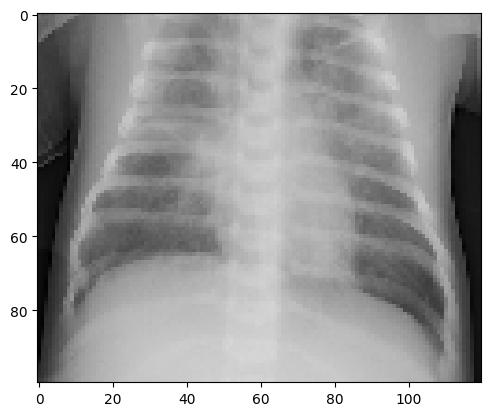

In [39]:
plt.imshow(x_train[1])

In [75]:
# -------------------------------
# Input layer
# -------------------------------
# Define input shape (H, W, 3 channels for RGB)
input_ = keras.layers.Input(shape=(H, W, 3))

# -------------------------------
# Rescaling
# -------------------------------
# Scale pixel values from [0, 255] to [0, 1]
x = keras.layers.Rescaling(1./255)(input_)

# -------------------------------
# First Convolutional Block
# -------------------------------
# Conv2D layer with 100 filters, 3x3 kernel, same padding
hidden = keras.layers.Conv2D(100, kernel_size=(3,3), padding="same",
kernel_initializer="he_normal")(x)
hidden = keras.layers.Conv2D(100, kernel_size=(3,3), padding="same",kernel_initializer="he_normal")(hidden)
# Batch normalization for stable training
hidden = keras.layers.BatchNormalization()(hidden)
# Activation
hidden = keras.layers.ReLU()(hidden)
# Max pooling to reduce spatial dimensions
hidden = keras.layers.MaxPool2D()(hidden)

# -------------------------------
# Second Convolutional Block
# -------------------------------
hidden = keras.layers.Conv2D(64, kernel_size=(3,3), padding="same",kernel_initializer="he_normal")(hidden)
hidden = keras.layers.Conv2D(64, kernel_size=(3,3), padding="same",kernel_initializer="he_normal")(hidden)
hidden = keras.layers.BatchNormalization()(hidden)
hidden = keras.layers.ReLU()(hidden)
hidden = keras.layers.MaxPool2D()(hidden)

# -------------------------------
# Flatten and Dense Layers
# -------------------------------
hidden = keras.layers.Flatten()(hidden)

# Fully connected layer with 700 neurons
hidden = keras.layers.Dense(700, kernel_initializer="he_normal")(hidden)
hidden = keras.layers.BatchNormalization()(hidden)
hidden = keras.layers.ReLU()(hidden)

# Fully connected layer with 500 neurons
hidden = keras.layers.Dense(500, kernel_initializer="he_normal")(hidden)
hidden = keras.layers.BatchNormalization()(hidden)
hidden = keras.layers.ReLU()(hidden)

# Output layer (binary classification)
output_ = keras.layers.Dense(1, activation='sigmoid',kernel_initializer="he_normal")(hidden)

# -------------------------------
# Create Model
# -------------------------------
model = keras.Model(inputs=input_, outputs=output_)

# Print summary of the model
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_9 (InputLayer)      │ (None, 100, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_7 (Rescaling)         │ (None, 100, 120, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 100, 120, 100)  │         2,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 100, 120, 100)  │        90,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_40          │ (None, 100, 120, 100)  │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_40 (ReLU)                 │ (None, 100, 120, 100)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 50, 60, 100)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_34 (Conv2D)              │ (None, 50, 60, 64)     │        57,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 50, 60, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_41          │ (None, 50, 60, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_41 (ReLU)                 │ (None, 50, 60, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_27 (MaxPooling2D) │ (None, 25, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 48000)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 700)            │    33,600,700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_42          │ (None, 700)            │         2,800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_42 (ReLU)                 │ (None, 700)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 500)            │       350,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_43          │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_43 (ReLU)                 │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 1)              │           501 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 34,144,649 (130.25 MB)

 Trainable params: 34,141,921 (130.24 MB)

 Non-trainable params: 2,728 (10.66 KB)

In [76]:
optimizer = keras.optimizers.Adam(learning_rate=0.001)
model.compile(optimizer=optimizer , loss="binary_crossentropy" ,metrics=["accuracy"])

In [77]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',          # Metric to monitor (validation loss)
    patience=3,                  # Number of epochs to wait before stopping if no improvement
    restore_best_weights=True    # Restore model weights from the epoch with the best value
)

In [78]:
history = model.fit(x=x_train , y=y_train , batch_size=32 , epochs=20 , validation_data=(x_test , y_test) ,callbacks=[early_stop])

Epoch 1/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 39s 144ms/step - accuracy: 0.9490 - loss: 0.1386 - val_accuracy: 0.5023 - val_loss: 4.4467
Epoch 2/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 23s 110ms/step - accuracy: 0.9748 - loss: 0.0690 - val_accuracy: 0.9619 - val_loss: 0.1077
Epoch 3/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - accuracy: 0.9848 - loss: 0.0432 - val_accuracy: 0.5557 - val_loss: 3.1097
Epoch 4/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 22s 104ms/step - accuracy: 0.9896 - loss: 0.0327 - val_accuracy: 0.9467 - val_loss: 0.2203
Epoch 5/20
214/214 ━━━━━━━━━━━━━━━━━━━━ 23s 106ms/step - accuracy: 0.9930 - loss: 0.0191 - val_accuracy: 0.9707 - val_loss: 0.1092


Text(0, 0.5, 'Accuracy')

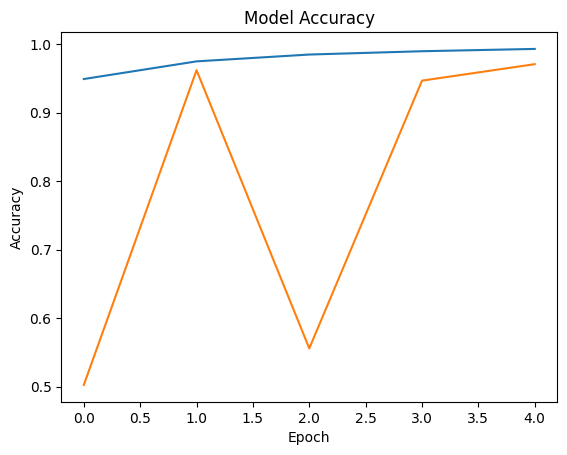

In [82]:
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

Text(0, 0.5, 'loss')

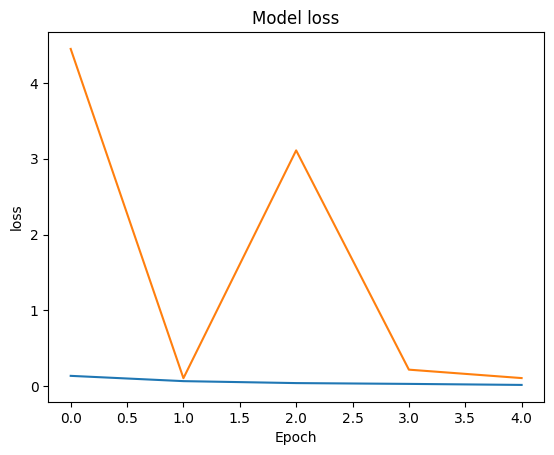

In [83]:
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.title("Model loss")
plt.xlabel("Epoch")
plt.ylabel("loss")

In [79]:
model.evaluate(x_test  , y_test)

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.9619 - loss: 0.1077


[0.1077360212802887, 0.9618991613388062]

In [96]:
y_pred_test = model.predict(x_test)
y_pred_test = (y_pred_test > 0.5).astype(int)

54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step


In [97]:
from sklearn.metrics import classification_report

print(classification_report(y_test  , y_pred_test))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       855
           1       0.96      0.96      0.96       851

    accuracy                           0.96      1706
   macro avg       0.96      0.96      0.96      1706
weighted avg       0.96      0.96      0.96      1706



In [98]:
y_pred_train = model.predict(x_train)
y_pred_train = (y_pred_train > 0.5).astype(int)

214/214 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step


In [99]:
print(classification_report(y_train  , y_pred_train))

              precision    recall  f1-score   support

           0       0.98      0.97      0.97      3410
           1       0.97      0.98      0.97      3414

    accuracy                           0.97      6824
   macro avg       0.97      0.97      0.97      6824
weighted avg       0.97      0.97      0.97      6824

